# The Block-Trade Signal — can you ride a whale's coattails? 🐋
### When a giant trade crosses the tape, is it smart money — and can you copy it?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Here's a piece of trading-floor folklore as old as the ticker tape. Every so often a **giant block** prints — a single trade far bigger than everything around it. The story says: *that's an institution who knows something, crossing size.* If you can tell which way they went (buying or selling) and jump on the same side, you'll **ride their coattails** as the stock drifts their way.

Sounds great. But the microstructure researchers who actually studied blocks found something inconvenient: most giant blocks aren't *informed* at all — they're a big fund **rebalancing**, willing to pay a temporary price concession to get it done, and the price **snaps back** afterward. Copy that and you *lose*.

So which is it — informed drift, or a liquidity trap that reverts?

> ⚠️ **We can't answer it on real data — and that's the point of this study.** To even *see* a block you need the intraday trade-by-trade tape *and* the quotes to tell buy from sell. A free retail feed gives you a daily *volume* number and nothing else. So we build a **synthetic** block-trade world we fully control, and use it to show what the signal would look like if it were real, if it reversed, and if it were nothing.
>
> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from block_trade_signal import data, strategy as st

# Two deterministic worlds share one schema (seed 562): the NULL (no block->drift) and a
# literature-modest planted edge. Synthetic-only: there is no real block tape to fetch.
NULL, _  = data.synthetic_panel(drift_alpha=0.0)
POS,  _  = data.synthetic_panel(drift_alpha=0.006)
print("synthetic-only study - no real tape.")
print("null panel fp   :", data.fingerprint(NULL), " events:", len(NULL))
print("planted panel fp:", data.fingerprint(POS),  " events:", len(POS))


synthetic-only study - no real tape.
null panel fp   : cd3cabd17906  events: 1200
planted panel fp: dc3dd07ca2da  events: 1200


## The answer first 🎯

| Question | Answer |
|---|---|
| Does copying a giant block earn a drift? | **In an honest coin-flip world, no.** With no real block→drift relation the coattail earns **-0.004%** per event (*t* -0.04), hit rate **49.5%** — a coin. |
| Could it ever work? | **Yes, if blocks were informed** — but it could equally *reverse* (if they're liquidity trades). The literature is split on the very sign. |
| Can we settle it on real data? | **No.** No free feed can even *see* a classified block — you need the paid intraday tape + quotes. This study is **synthetic-only**. |
| Could you trade it? | **No.** You can't cheaply observe the signal, and chasing a block means crossing the spread into a *dislocated* price — costs bite hard. |

> The coattail is a great story with real academic backing on *both* sides (informed drift vs. liquidity reversal) — but on a free stack you can neither see it nor trade it, so it earns **Weak × Mirage**.

## 1 · The claim

> *"A large block-trade print is an informed institution crossing size; the stock will drift in the direction of that flow."* — trading-floor folklore, with a theoretical backbone (Easley & O'Hara 1987: informed traders prefer to trade *big*, so trade size itself carries information).

The coattail trade is simple: watch the tape for a giant print, work out whether it was buyer- or seller-initiated, take the *same* side, and hold for the drift. The whole bet is that the block *knew something*.

## 2 · So what?

If blocks really are informed, the tape hands you a free signal every day — just follow the whales. But the microstructure literature says the opposite is at least as likely: Holthausen-Leftwich-Mayers and Keim-Madhavan showed that a big chunk of a block's price move is a **temporary concession** the initiator pays for immediacy, which then **reverts**. Same block, opposite trade. The desk has looked at daily *volume* signals ([512](../../512-high-volume-return-premium/), [492](../../492-up-down-volume/)); this study goes at the *single classified block print* and its **direction**.

## 3 · How would we even know?

1. **Spot the block.** A print far bigger than the stock's normal trade size.
2. **Guess its side.** Buyer- or seller-initiated, from a quote rule (imperfect — it gets the side wrong maybe 1 time in 7).
3. **Copy it.** Take the same side, hold a few days, measure the P&L.
4. **Repeat over thousands of blocks** and ask: does copying blocks earn a drift different from zero?

The catch that forces this study to be **synthetic**: steps 1 and 2 need the *trade-by-trade tape and the quotes* — paid data. A free feed gives you one daily volume number, which is *not* a block and has *no* direction. So we build the block world in code, with a single knob that decides whether blocks are informed, reversing, or nothing — and let the machinery loose on it.

*Timing:* the coattail is entered **after** the block prints (the signal is public the instant it crosses the tape) and held over the forward window. No peeking — one clean execution lag.

## 4 · The teardown — the honest coin-flip world

First the **null**: a world where a block tells you *nothing*. If the machinery is honest it should find no drift here.

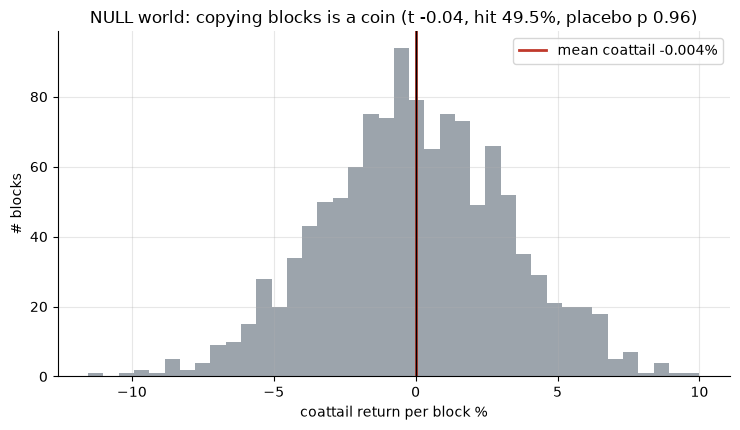

coattail mean -0.004% | t -0.04 | hit 49.5% | placebo p 0.964


In [2]:
cs = st.coattail_stats(NULL)
p  = st.placebo_pvalue(NULL, n_perm=2000)
mean, t, hit = cs['mean']*100, cs['t'], cs['hit']*100
up = (NULL['fwd_ret'] > 0).mean()*100
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.hist(NULL['fwd_ret']*100, bins=40, color=GREY, alpha=.85)
ax.axvline(mean, c=RED, lw=2, label=f'mean coattail {mean:+.3f}%')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('coattail return per block %'); ax.set_ylabel('# blocks')
ax.set_title(f'NULL world: copying blocks is a coin (t {t:+.2f}, hit {hit:.1f}%, placebo p {p:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'coattail mean {mean:+.3f}% | t {t:+.2f} | hit {hit:.1f}% | placebo p {p:.3f}')

There it is — **nothing.** The coattail earns **-0.004%** per block (*t* -0.04), wins **49.5%** of the time (a coin), and the placebo test puts the odds at *p* = 0.964. When blocks carry no information, copying them is a coin flip — exactly as it should be. This is the world the real market *might* be, and we have no real tape to rule it out.

**Now flip the knob on.** Plant a *modest* informed edge (correctly-signed giant blocks drift the coattail's way) and re-run — do bigger blocks drift more?

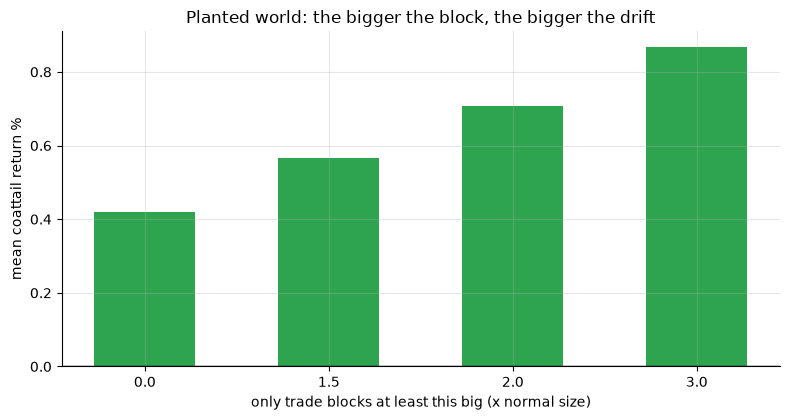

               mean       t     n     hit
min_block_z                              
0.0          0.0042  4.3229  1200  0.5500
1.5          0.0057  4.4945   713  0.5694
2.0          0.0071  4.2796   439  0.5923
3.0          0.0087  3.0931   159  0.6226


In [3]:
sw = st.robustness_sweep(POS)
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar([str(x) for x in sw.index], sw['mean']*100, color=GREEN, width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('only trade blocks at least this big (x normal size)')
ax.set_ylabel('mean coattail return %')
ax.set_title('Planted world: the bigger the block, the bigger the drift')
plt.tight_layout(); plt.show()
print(sw.round(4).to_string())

In the planted world the drift **grows with block size** — the giant prints drift most, just as the folklore claims. That's the shape a *real* informed-block signal would have. But remember: **we planted it.** The whole question is whether the real tape looks like this world or the coin-flip one — and no free data can tell us.

## 5 · The verdict

- **Signal — Weak.** The idea has real academic support, but it fights an equally documented *reversal*, and we can't certify either on a real tape (synthetic-only). On the honest null the coattail is a coin (*t* -0.04, placebo *p* 0.964).
- **Tradability — Mirage.** You can't cheaply *see* a classified block, and chasing one means crossing into a dislocated price. Nothing to trade on a retail stack.

## 6 · Could you actually trade it?

No — twice over. First, you can't *observe* the signal: seeing a block and its side needs the paid intraday tape and quotes, not the daily bars a free feed gives you. Second, even in the planted world where the edge is real, **chasing a block means buying into the very print that just dislocated the price** — you pay the spread on a moved market. Those frictions eat roughly 40% of a modest edge (see the quants notebook). Great story, unreachable trade.

## 7 · Going further 🚪

- **The volume cousins.** [512 High-Volume-Return-Premium](../../512-high-volume-return-premium/) and [492 Up-Down-Volume](../../492-up-down-volume/) use *daily* volume — no block, no side. This study is the *single classified print*.
- **Informed flow you *can* see.** [263 Insider-Buying](../../263-insider-buying/) uses disclosed insider trades (Form 4) — informedness with a real, free tape.
- **The real test needs the tape.** Re-run this with genuine TAQ prints + Lee-Ready signs + survivorship-free returns — that's where the informed-vs-liquidity sign gets settled.

*Think blocks really are informed? Fork this, feed it a real classified-block tape, and show the coattail clearing t = 2 the right way — after the spread you pay to chase it.*